In [1]:
# ============================================
# 03_analisis.ipynb — Análisis de datos Bizi
# Proyecto: DataZ Movility (Fase A — Bizi)
# Autor: Miguel
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

DATA_PROCESSED = Path("../data/processed")

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


In [2]:
df = pd.read_csv(DATA_PROCESSED / "bizi_clean.csv")

df.head()


,station_id,station_name,status,bikes,slots,capacity,ratio_ocupacion,ocupacion_categoria,lon,lat,lastUpdated
0,279,193- Pza. La Ermita,IN_SERVICE,1,18,19,0.052632,baja,-0.911216,41.631495,2026-02-25 17:08:07+00:00
1,278,270- Delicias Autobuses,IN_SERVICE,0,19,19,0.000000,baja,-0.910784,41.659517,2026-02-25 17:08:07+00:00
2,277,150- Mrio. Siresa: Dr. Iranzo,IN_SERVICE,11,8,19,0.578947,media,-0.864099,41.647586,2026-02-25 17:08:07+00:00
3,274,190- Puerto Venecia Este,IN_SERVICE,26,15,41,0.634146,media,-0.883953,41.608225,2026-02-25 17:08:07+00:00
4,273,224- Manuel Viola,IN_SERVICE,3,16,19,0.157895,baja,-0.857295,41.659139,2026-02-25 17:08:07+00:00


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_id           274 non-null    int64  
 1   station_name         274 non-null    str    
 2   status               274 non-null    str    
 3   bikes                274 non-null    int64  
 4   slots                274 non-null    int64  
 5   capacity             274 non-null    int64  
 6   ratio_ocupacion      274 non-null    float64
 7   ocupacion_categoria  274 non-null    str    
 8   lon                  274 non-null    float64
 9   lat                  274 non-null    float64
 10  lastUpdated          274 non-null    str    
dtypes: float64(3), int64(4), str(4)
memory usage: 23.7 KB


In [4]:
df.describe(include="all")


,station_id,station_name,status,bikes,slots,capacity,ratio_ocupacion,ocupacion_categoria,lon,lat,lastUpdated
count,274.000000,274,274,274.000000,274.000000,274.000000,274.000000,274,274.000000,274.000000,274
unique,NaN,274,1,NaN,NaN,NaN,NaN,3,NaN,NaN,5
top,NaN,193- Pza. La Ermita,IN_SERVICE,NaN,NaN,NaN,NaN,baja,NaN,NaN,2026-02-25 17:08:03+00:00
freq,NaN,1,274,NaN,NaN,NaN,NaN,142,NaN,NaN,75
mean,139.335766,NaN,NaN,6.182482,13.189781,19.372263,0.320757,NaN,-0.894000,41.648554,NaN
std,79.979785,NaN,NaN,5.211595,5.563530,3.108554,0.269016,NaN,0.025744,0.015976,NaN
min,2.000000,NaN,NaN,0.000000,0.000000,13.000000,0.000000,NaN,-0.962323,41.608225,NaN
25%,70.250000,NaN,NaN,2.000000,10.000000,18.000000,0.105263,NaN,-0.912256,41.637811,NaN
50%,139.500000,NaN,NaN,5.000000,14.000000,19.000000,0.277778,NaN,-0.890296,41.648402,NaN
75%,207.750000,NaN,NaN,9.000000,17.000000,19.000000,0.495370,NaN,-0.875525,41.658974,NaN


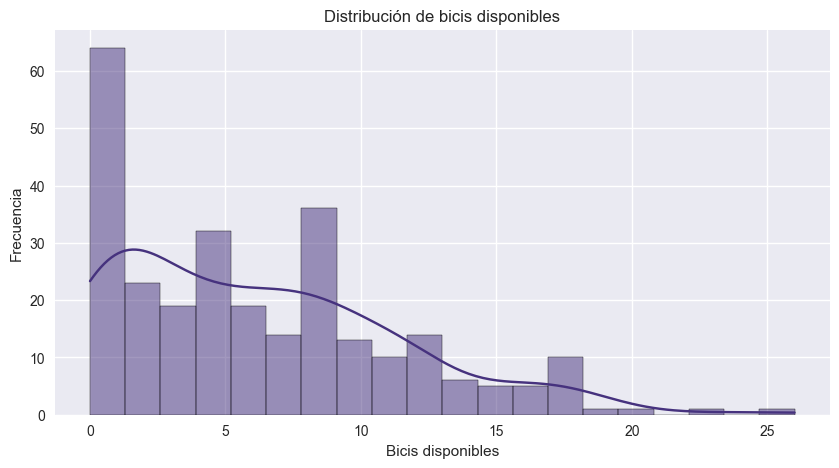

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["bikes"], bins=20, kde=True)
plt.title("Distribución de bicis disponibles")
plt.xlabel("Bicis disponibles")
plt.ylabel("Frecuencia")
plt.show()


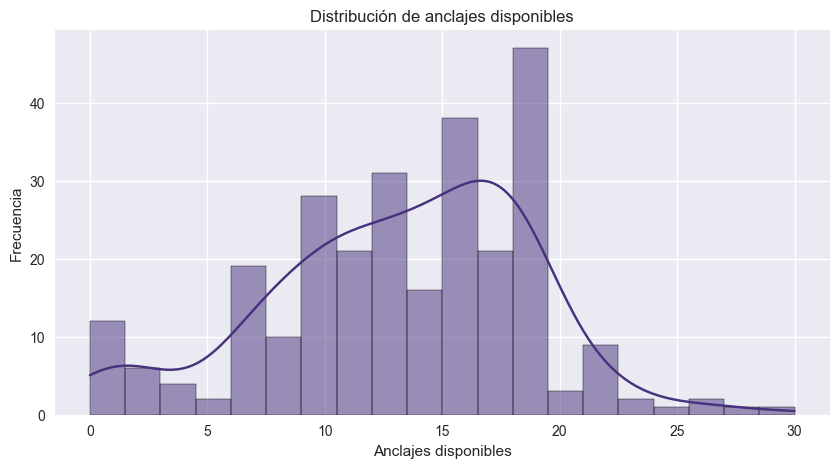

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df["slots"], bins=20, kde=True)
plt.title("Distribución de anclajes disponibles")
plt.xlabel("Anclajes disponibles")
plt.ylabel("Frecuencia")
plt.show()


In [7]:
top_saturadas = df.sort_values("ratio_ocupacion", ascending=False).head(10)

top_saturadas[["station_name", "bikes", "slots", "ratio_ocupacion"]]


,station_name,bikes,slots,ratio_ocupacion
245,4-Atarés: Pte. Almozara,19,0,1.000000
117,159-Parq. La Granja: Galiay,15,0,1.000000
194,93-Matadero,18,0,1.000000
208,37-Ballesteros,18,0,1.000000
270,70-Picasso: Zambrano,18,0,1.000000
228,47-S. Francisco: Universidad,23,0,1.000000
41,192- Olivar: Quirón,18,1,0.947368
262,57-Sobrarbe: Ribera,18,1,0.947368
115,165-Pza. Mayor,18,1,0.947368
157,88-M.ª Callas: Casanova,16,1,0.941176


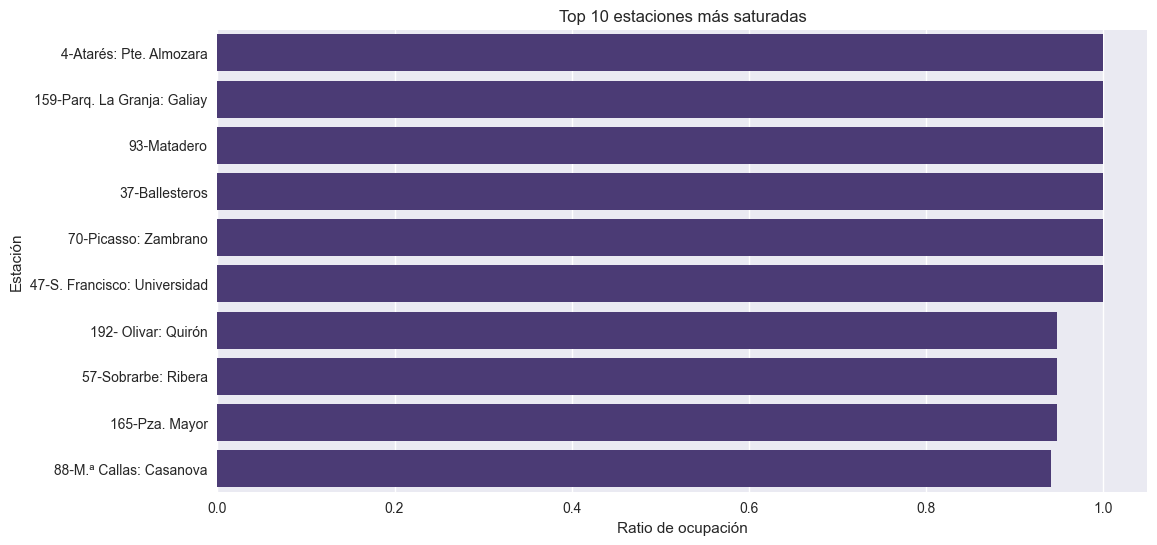

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_saturadas,
    x="ratio_ocupacion",
    y="station_name"
)
plt.title("Top 10 estaciones más saturadas")
plt.xlabel("Ratio de ocupación")
plt.ylabel("Estación")
plt.show()


In [9]:
top_vacias = df.sort_values("ratio_ocupacion", ascending=True).head(10)

top_vacias[["station_name", "bikes", "slots", "ratio_ocupacion"]]


,station_name,bikes,slots,ratio_ocupacion
1,270- Delicias Autobuses,0,19,0.0
21,220- Isla del Tesoro: Titanic,0,21,0.0
35,223- Ilustración 21,0,19,0.0
39,244- Gmez. Laguna: Hayedo,0,18,0.0
232,104-Madre Rafols: DGA,0,19,0.0
58,253- Rguez. Ayuso 58,0,19,0.0
226,15-Portillo,0,18,0.0
63,259- Cno. Pilón: Oriz García,0,19,0.0
72,203- Lagos Llosas: Solana,0,19,0.0
235,89-Echegaray: Postigo Ebro,0,20,0.0


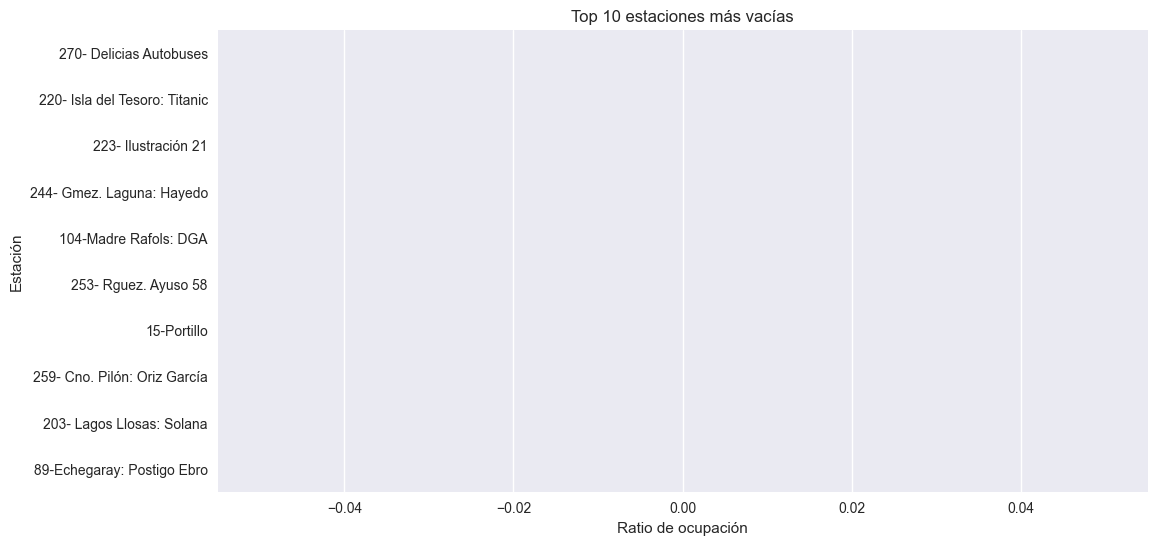

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_vacias,
    x="ratio_ocupacion",
    y="station_name"
)
plt.title("Top 10 estaciones más vacías")
plt.xlabel("Ratio de ocupación")
plt.ylabel("Estación")
plt.show()


In [11]:
df["ocupacion_categoria"].value_counts()


ocupacion_categoria
baja     142
media    106
alta      26
Name: count, dtype: int64

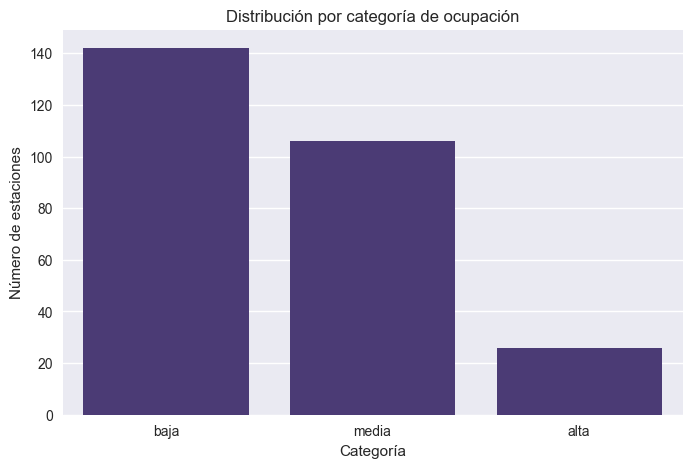

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ocupacion_categoria")
plt.title("Distribución por categoría de ocupación")
plt.xlabel("Categoría")
plt.ylabel("Número de estaciones")
plt.show()


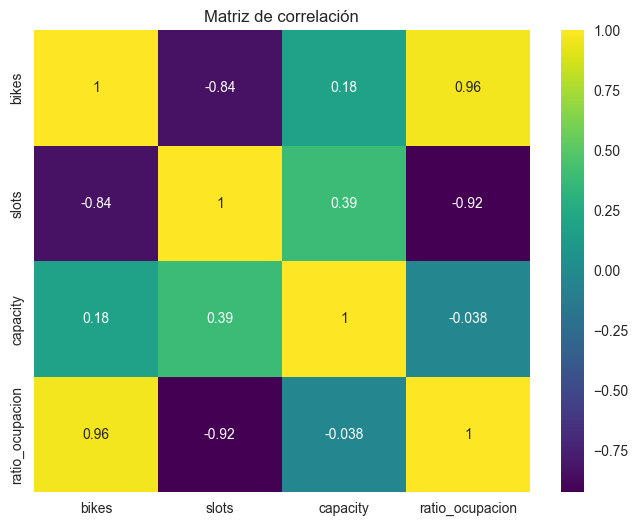

In [13]:
corr = df[["bikes", "slots", "capacity", "ratio_ocupacion"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Matriz de correlación")
plt.show()


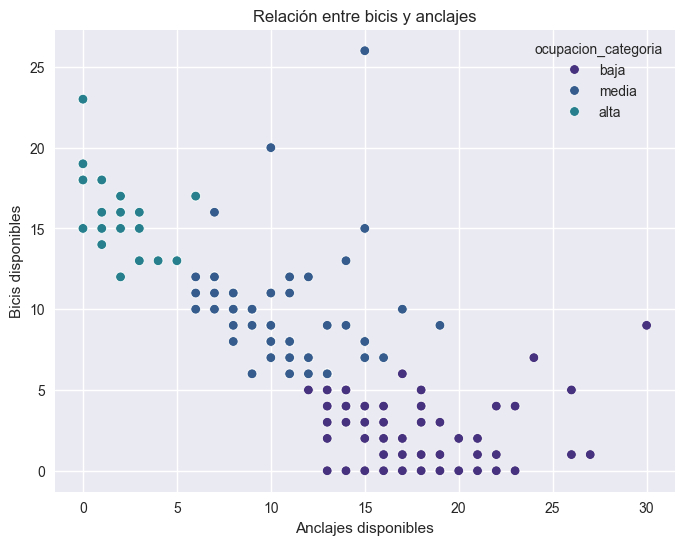

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="slots", y="bikes", hue="ocupacion_categoria")
plt.title("Relación entre bicis y anclajes")
plt.xlabel("Anclajes disponibles")
plt.ylabel("Bicis disponibles")
plt.show()


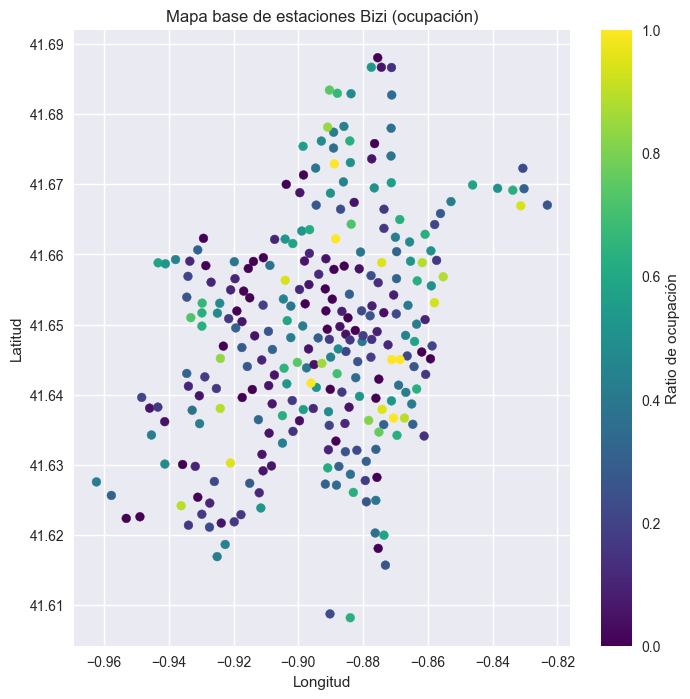

In [15]:
plt.figure(figsize=(8,8))
plt.scatter(df["lon"], df["lat"], c=df["ratio_ocupacion"], cmap="viridis", s=40)
plt.colorbar(label="Ratio de ocupación")
plt.title("Mapa base de estaciones Bizi (ocupación)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


In [16]:
criticas = df[df["ocupacion_categoria"] == "alta"]

criticas[["station_name", "bikes", "slots", "ratio_ocupacion"]].head(15)


,station_name,bikes,slots,ratio_ocupacion
13,222- Americano París: Jard. Alá,17,2,0.894737
14,146- Pza. Serrano Berges,15,1,0.937500
41,192- Olivar: Quirón,18,1,0.947368
50,245- Campillo Llerena,16,2,0.888889
53,243- Anillo Verde: Rguez. Ayuso,15,3,0.833333
82,201-Lagos Coronas: Leyva,13,5,0.722222
98,264-Burriel: Zapater,15,2,0.882353
114,267-Príncipe Felipe,17,2,0.894737
115,165-Pza. Mayor,18,1,0.947368
117,159-Parq. La Granja: Galiay,15,0,1.000000


In [17]:
df.to_csv(DATA_PROCESSED / "bizi_analisis_resultados.csv", index=False)
print("Resultados guardados.")


Resultados guardados.
